## Classification Model

### Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## pre process
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

## metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

### Data Fetch - Classification Model

In [2]:
import os
os.chdir(r'C:\Users\AnuragS\OneDrive\cv_project\2 Stage Loan Approval & Validation System\data')
os.getcwd()

'C:\\Users\\AnuragS\\OneDrive\\cv_project\\2 Stage Loan Approval & Validation System\\data'

In [3]:
df = pd.read_csv('classification_data.csv')
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,total_assets,loan_income_ratio,asset_coverage_ratio,income_per_dependent,wealth_cibil_score,loan_status
0,2,1,0,9600000,29900000,12,778,50700000.0,3.114583,1.695652,3.200000e+06,3.944460e+10,1
1,0,0,1,4100000,12200000,8,417,17000000.0,2.975610,1.393443,4.100000e+06,7.089000e+09,0
2,3,1,0,9100000,29700000,20,506,57700000.0,3.263736,1.942761,2.275000e+06,2.919620e+10,0
3,3,1,0,8200000,30700000,8,467,52700000.0,3.743902,1.716612,2.050000e+06,2.461090e+10,0
4,5,0,1,9800000,24200000,20,382,55000000.0,2.469388,2.272727,1.633333e+06,2.101000e+10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   no_of_dependents      4269 non-null   int64  
 1   education             4269 non-null   int64  
 2   self_employed         4269 non-null   int64  
 3   income_annum          4269 non-null   int64  
 4   loan_amount           4269 non-null   int64  
 5   loan_term             4269 non-null   int64  
 6   cibil_score           4269 non-null   int64  
 7   total_assets          4269 non-null   float64
 8   loan_income_ratio     4269 non-null   float64
 9   asset_coverage_ratio  4269 non-null   float64
 10  income_per_dependent  4269 non-null   float64
 11  wealth_cibil_score    4269 non-null   float64
 12  loan_status           4269 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 433.7 KB


#### Define X & y

In [5]:
X = df.drop('loan_status',axis=1)
y = df['loan_status']

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')

Shape of X: (4269, 12)
Shape of y: (4269,)


#### Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(3415, 12)
(854, 12)


#### Logistic Regression

In [7]:
logistic_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

logistic_reg_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_reg_pipeline.predict(X_test)

y_prob_lr = logistic_reg_pipeline.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION")

classification_report_lr = classification_report(y_test,y_pred_lr)
roc_auc_lr = roc_auc_score(y_test,y_pred_lr)
accuracy_lr = accuracy_score(y_test,y_pred_lr)
precision_lr = precision_score(y_test,y_pred_lr)
recall_lr = recall_score(y_test,y_pred_lr)
f1_lr = f1_score(y_test,y_pred_lr)

print(classification_report_lr)

print("ROC AUC:",roc_auc_lr)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.91      0.91      0.91       854

ROC AUC: 0.9057943129675302


#### Random Forest

In [8]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

print("RANDOM FOREST")

classification_report_rf = classification_report(y_test,y_pred_rf)
roc_auc_rf = roc_auc_score(y_test,y_pred_rf)
accuracy_rf = accuracy_score(y_test,y_pred_rf)
precision_rf = precision_score(y_test,y_pred_rf)
recall_rf = recall_score(y_test,y_pred_rf)
f1_rf = f1_score(y_test,y_pred_rf)

print(classification_report_rf)

print("ROC AUC:",roc_auc_rf)

RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       323
           1       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

ROC AUC: 0.9953560371517028


#### XGBoost

In [9]:
xgb = XGBClassifier()

xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

print("XGBOOST")

classification_report_xgb = classification_report(y_test,y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test,y_pred_xgb)
accuracy_xgb = accuracy_score(y_test,y_pred_xgb)
precision_xgb = precision_score(y_test,y_pred_xgb)
recall_xgb = recall_score(y_test,y_pred_xgb)
f1_xgb = f1_score(y_test,y_pred_xgb)

print(classification_report_xgb)

print("ROC AUC:",roc_auc_xgb)

XGBOOST
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       323
           1       1.00      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

ROC AUC: 0.9959624051821145


#### Model Comparison

In [10]:
model_names = ['Logistic Regression','Random Forest','XGBoost']
accuracy_scores = [accuracy_lr,accuracy_rf,accuracy_xgb]
precision_scores = [precision_lr,precision_rf,precision_xgb]
recall_scores = [recall_lr,recall_rf,recall_xgb]
f1_scores = [f1_lr,f1_rf,f1_xgb]
roc_auc_scores = [roc_auc_lr,roc_auc_rf,roc_auc_xgb]


results = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall':recall_scores,
    'F1':f1_scores,
    'ROC_AUC':roc_auc_scores
})

results.sort_values('ROC_AUC',ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.996487,0.996241,0.998117,0.997178,0.995962
1,Random Forest,0.996487,0.994382,1.000000,0.997183,0.995356
0,Logistic Regression,0.914520,0.922509,0.941620,0.931966,0.905794


### Interpretation
**Logistic Regression** : Logistic Regression achieved a ROC-AUC of 90.58%, indicating that loan approval decisions cannot be fully explained by linear relationships alone.

**Random Forest** : Random Forest significantly improved performance, achieving a ROC-AUC of 99.54%, suggesting that non-linear patterns and feature interactions play a major role in loan approval decisions.

**XGBoost**: XGBoost delivered the best overall performance with a ROC-AUC of 99.60% and F1-score of 99.72%, making it the strongest candidate for the final classification model.

From the analysis we saw that XGBoost and Random Forest are giving higher accuracy, so we will consider these two model for hyper parameter tuning.

## Hyperparameter Tuning

##### Random Forest

In [13]:
rf_params = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_hpt = RandomForestClassifier(random_state=42)

rf_search = RandomizedSearchCV(
    estimator=rf_hpt,
    param_distributions=rf_params,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest ROC AUC:")
print(rf_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}

Best ROC AUC:
0.9996023711810306


#### Evaluation of Random Forest (Tuned)

In [16]:
best_estimators_rf = rf_search.best_estimator_

y_pred_rf_hpt = best_estimators_rf.predict(X_test)

y_prob_rf_hpt = best_estimators_rf.predict_proba(X_test)[:,1]

classification_report_rf_hpt = classification_report(y_test,y_pred_rf_hpt)
roc_auc_rf_hpt = roc_auc_score(y_test,y_pred_rf_hpt)
accuracy_rf_hpt = accuracy_score(y_test,y_pred_rf_hpt)
precision_rf_hpt = precision_score(y_test,y_pred_rf_hpt)
recall_rf_hpt = recall_score(y_test,y_pred_rf_hpt)
f1_rf_hpt = f1_score(y_test,y_pred_rf_hpt)

print(classification_report_rf_hpt)

print("ROC AUC:",roc_auc_rf_hpt)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       323
           1       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

ROC AUC: 0.9953560371517028


#### XGBoost

In [17]:
xgb_params = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

xgb_hpt = XGBClassifier(eval_metric='logloss',random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb_hpt,
    param_distributions=xgb_params,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest ROC AUC:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}

Best ROC AUC:
0.9994965800273597


#### Evaluation of XGBoost (Tuned)

In [19]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb_hpt = best_xgb.predict(X_test)

y_prob_xgb_hpt = best_xgb.predict_proba(X_test)[:,1]


classification_report_xgb_hpt = classification_report(y_test,y_pred_xgb_hpt)
roc_auc_xgb_hpt = roc_auc_score(y_test,y_pred_xgb_hpt)
accuracy_xgb_hpt = accuracy_score(y_test,y_pred_xgb_hpt)
precision_xgb_hpt = precision_score(y_test,y_pred_xgb_hpt)
recall_xgb_hpt = recall_score(y_test,y_pred_xgb_hpt)
f1_xgb_hpt = f1_score(y_test,y_pred_xgb_hpt)


print(classification_report_xgb_hpt)

print("ROC AUC:", roc_auc_xgb_hpt )

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       323
           1       0.99      1.00      1.00       531

    accuracy                           0.99       854
   macro avg       0.99      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854

ROC AUC: 0.9928664299499164


#### Baseline vs Tuned

In [20]:
model_names = ['RF Baseline','RF Tuned','XGB Baseline','XGB Tuned']
roc_auc_scores = [roc_auc_rf,roc_auc_rf_hpt,roc_auc_xgb,roc_auc_xgb_hpt]


comparison = pd.DataFrame({
    'Model':model_names,
    'ROC_AUC':roc_auc_scores
})

comparison.sort_values(
    'ROC_AUC',
    ascending=False
)

,Model,ROC_AUC
2,XGB Baseline,0.995962
0,RF Baseline,0.995356
1,RF Tuned,0.995356
3,XGB Tuned,0.992866


Four models were evaluated: Logistic Regression, Random Forest, Tuned Random Forest, and Tuned XGBoost. XGBoost Baseline achieved the highest ROC-AUC score of 99.60%, outperforming all other models. Hyperparameter tuning did not improve performance; in fact, the tuned XGBoost model showed a slight decline in ROC-AUC. Therefore, the baseline XGBoost model was selected as the final loan approval classifier.

## Feature Importance (XGB Baseline)

In [22]:
classification_features = list(X.columns)

feature_importance = pd.DataFrame({
    'Feature': classification_features,
    'Importance': xgb.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
6,cibil_score,0.716977
8,loan_income_ratio,0.138078
5,loan_term,0.106755
9,asset_coverage_ratio,0.017032
1,education,0.004800
11,wealth_cibil_score,0.003747
4,loan_amount,0.002688
0,no_of_dependents,0.002372
10,income_per_dependent,0.002056
2,self_employed,0.001993


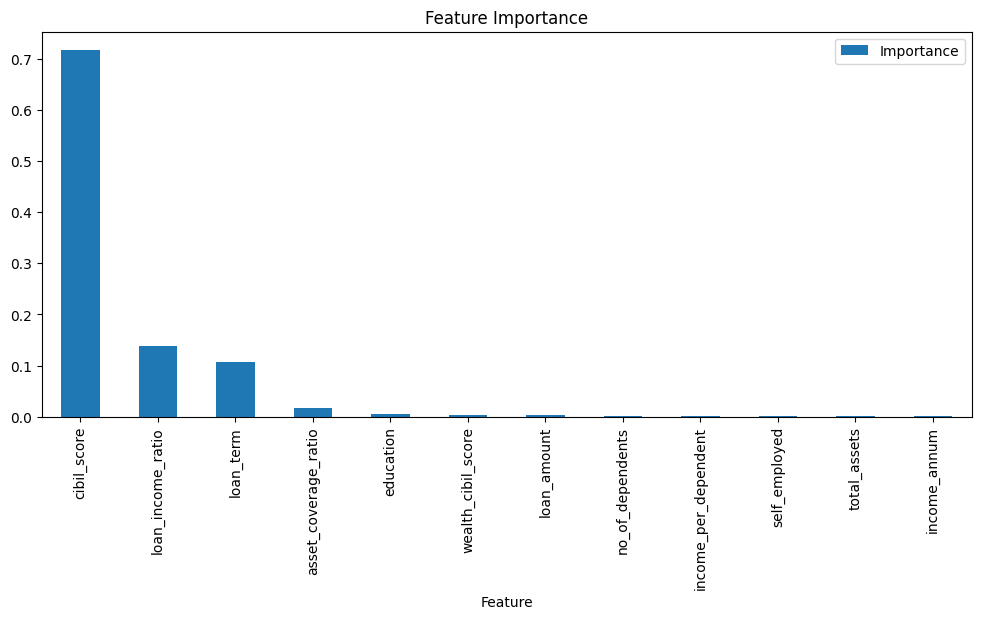

In [24]:
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(12,5)
)

plt.title("Feature Importance")
plt.show()

Feature importance analysis revealed that CIBIL score is the dominant driver of loan approval decisions, contributing approximately 72% of the model's predictive power. Loan affordability indicators, specifically loan-to-income ratio and loan term, were the next most important factors. Demographic variables such as education, employment status, and number of dependents had minimal impact on approval outcomes. These findings suggest that creditworthiness and repayment capacity are the primary determinants of loan approval in the dataset.

#### Load the pkl file

In [26]:
import joblib
os.makedirs("../model",exist_ok=True)

joblib.dump(xgb,"../model/loan_approval_model.pkl")

['../model/loan_approval_model.pkl']